# What Predicts Reading Behavior?
## A Data-Driven Exploration of Reading Habits

*Based on a survey of 2,832 Americans about their book-reading habits, demographics, and media consumption.*

---
## Chapter 1: Who Are We Studying?

Before diving into reading behavior, let's understand who makes up our sample. We have demographic data on **2,832 survey respondents** including their age, gender, race, education, employment, income, and marital status.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

df = pd.read_csv('BigML_Dataset_5f50a62795a9306aa200003e.csv')
print(f'Raw dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')

Raw dataset shape: 2832 rows, 14 columns


In [2]:
print('=== Missing Values (Before Cleaning) ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Missing Values (Before Cleaning) ===
Age                                                      0
Sex                                                      0
Race                                                     0
Marital status?                                          0
Education                                               58
Employement                                              0
Incomes                                                  0
How many books did you read during last 12months?        0
Read any printed books during last 12months?           390
Read any audiobooks during last 12months?              390
Read any e-books during last 12months?                 390
Last book you read, you…                               390
Do you happen to read any daily news or newspapers?      0
Do you happen to read any magazines or journals?         0
dtype: int64

Total missing: 1618


In [3]:
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'After removal: {df.shape[0]} rows')

Duplicate rows: 1
After removal: 2831 rows


In [4]:
print('Before fix - income values with issues:')
issues = df['Incomes'][df['Incomes'].str.contains(r'^9\$', na=False)]
print(issues.unique())
df['Incomes'] = df['Incomes'].replace(r'^9\$', '$', regex=True)
print('\nAfter fix:')
print(df['Incomes'].unique())

Before fix - income values with issues:
['9$100,000 to under $150,000']

After fix:
['$20,000 to under $30,000' 'Less than $10,000' '$40,000 to under $50,000'
 '$10,000 to under $20,000' '$50,000 to under $75,000'
 '$100,000 to under $150,000' '$75,000 to under $100,000'
 '$30,000 to under $40,000' 'Refused']


In [5]:
df.columns = [
    'age', 'gender', 'race', 'marital_status', 'education',
    'employment', 'income_bracket', 'books_read', 'read_printed',
    'read_audiobooks', 'read_ebooks', 'last_book_acquisition',
    'reads_news', 'reads_magazines'
]
print('Columns renamed:')
print(list(df.columns))

Columns renamed:
['age', 'gender', 'race', 'marital_status', 'education', 'employment', 'income_bracket', 'books_read', 'read_printed', 'read_audiobooks', 'read_ebooks', 'last_book_acquisition', 'reads_news', 'reads_magazines']


In [6]:
edu_before = df['education'].isnull().sum()
df['education'] = df['education'].fillna('Unknown')
edu_after = df['education'].isnull().sum()
print(f'Education nulls: {edu_before} -> {edu_after}')

Education nulls: 58 -> 0


In [7]:
reading_cols = ['read_printed', 'read_audiobooks', 'read_ebooks', 'last_book_acquisition']
nulls_before = df[reading_cols].isnull().sum().sum()
df.loc[df['books_read'] == 0, reading_cols] = 'Did not read any books'
nulls_after = df[reading_cols].isnull().sum().sum()
print(f'Reading columns nulls: {nulls_before} -> {nulls_after}')

Reading columns nulls: 1560 -> 0


In [8]:
print('=== Missing Values (After Cleaning) ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Missing Values (After Cleaning) ===
age                      0
gender                   0
race                     0
marital_status           0
education                0
employment               0
income_bracket           0
books_read               0
read_printed             0
read_audiobooks          0
read_ebooks              0
last_book_acquisition    0
reads_news               0
reads_magazines          0
dtype: int64

Total missing: 0


In [9]:
def detect_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR
    outliers = series[(series < LB) | (series > UB)]
    print(f'\n{name}:')
    print(f'  Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
    print(f'  Bounds: [{LB:.1f}, {UB:.1f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)')
    return outliers

print('=== Outlier Detection (IQR Method) ===')
age_outliers = detect_outliers_iqr(df['age'], 'Age')
book_outliers = detect_outliers_iqr(df['books_read'], 'Books Read')
print('\nNote: 97 in books_read represents a code for 97+ books, not a true outlier.')

=== Outlier Detection (IQR Method) ===

Age:
  Q1=32.0, Q3=62.0, IQR=30.0
  Bounds: [-13.0, 107.0]
  Outliers: 0 (0.0%)

Books Read:
  Q1=2.5, Q3=20.0, IQR=17.5
  Bounds: [-23.8, 46.2]
  Outliers: 317 (11.2%)

Note: 97 in books_read represents a code for 97+ books, not a true outlier.


In [10]:
print(f'Cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns\n')
df.head()

Cleaned dataset: 2831 rows, 14 columns



,age,gender,race,marital_status,education,employment,income_bracket,books_read,read_printed,read_audiobooks,read_ebooks,last_book_acquisition,reads_news,reads_magazines
0,66,Male,Refused,Divorced,College graduate,Retired,"$20,000 to under $30,000",97,Yes,No,Yes,Purchased the book,No,Yes
1,46,Male,Native American/American Indian,Married,High school graduate,Employed full-time,"Less than $10,000",97,Yes,Yes,Yes,Purchased the book,Yes,Yes
2,32,Male,Mixed race,Never been married,High school graduate,Employed full-time,"Less than $10,000",97,No,Yes,Yes,Borrowed the book from a friend or family member,Yes,Yes
3,27,Male,Mixed race,Married,High school graduate,Employed full-time,"$40,000 to under $50,000",97,Yes,No,Yes,Borrowed the book from a library,Yes,No
4,16,Female,Mixed race,Never been married,High school incomplete,Employed part-time,"$10,000 to under $20,000",97,Yes,Yes,No,Purchased the book,Yes,No


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2831 entries, 0 to 2831
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    2831 non-null   int64 
 1   gender                 2831 non-null   object
 2   race                   2831 non-null   object
 3   marital_status         2831 non-null   object
 4   education              2831 non-null   object
 5   employment             2831 non-null   object
 6   income_bracket         2831 non-null   object
 7   books_read             2831 non-null   int64 
 8   read_printed           2831 non-null   object
 9   read_audiobooks        2831 non-null   object
 10  read_ebooks            2831 non-null   object
 11  last_book_acquisition  2831 non-null   object
 12  reads_news             2831 non-null   object
 13  reads_magazines        2831 non-null   object
dtypes: int64(2), object(12)
memory usage: 331.8+ KB


In [12]:
df.describe(include='all')

,age,gender,race,marital_status,education,employment,income_bracket,books_read,read_printed,read_audiobooks,read_ebooks,last_book_acquisition,reads_news,reads_magazines
count,2831.000000,2831,2831,2831,2831,2831,2831,2831.000000,2831,2831,2831,2831,2831,2831
unique,NaN,2,8,8,8,8,9,NaN,4,4,4,7,3,3
top,NaN,Female,White,Married,High school graduate,Employed full-time,"$100,000 to under $150,000",NaN,Yes,No,No,Purchased the book,Yes,Yes
freq,NaN,1479,2216,1531,688,1238,742,NaN,2263,2026,1641,1265,1749,1505
mean,47.270223,NaN,NaN,NaN,NaN,NaN,NaN,16.677852,NaN,NaN,NaN,NaN,NaN,NaN
std,18.565806,NaN,NaN,NaN,NaN,NaN,NaN,23.636082,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN
50%,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,62.000000,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| Missing values | Checked before cleaning | 58 in Education, 390 in 4 reading columns |
| Duplicates | Removed | 1 duplicate row removed |
| Data entry error | Fixed `9$100,000...` to `$100,000...` | Income column cleaned |
| Column names | Renamed to snake_case | Readable, consistent naming |
| Education nulls | Filled with 'Unknown' | 58 nulls resolved |
| Reading columns | Filled for non-readers (books=0) | 390 nulls per column resolved |
| Outliers (Age) | IQR method | 0 outliers (all ages 16-93 valid) |
| Outliers (Books) | IQR method | 317 outliers (code 97 = 97+ books) |

### Gender Distribution

The survey has a slight female majority -- consistent with national survey patterns where women tend to respond at higher rates.

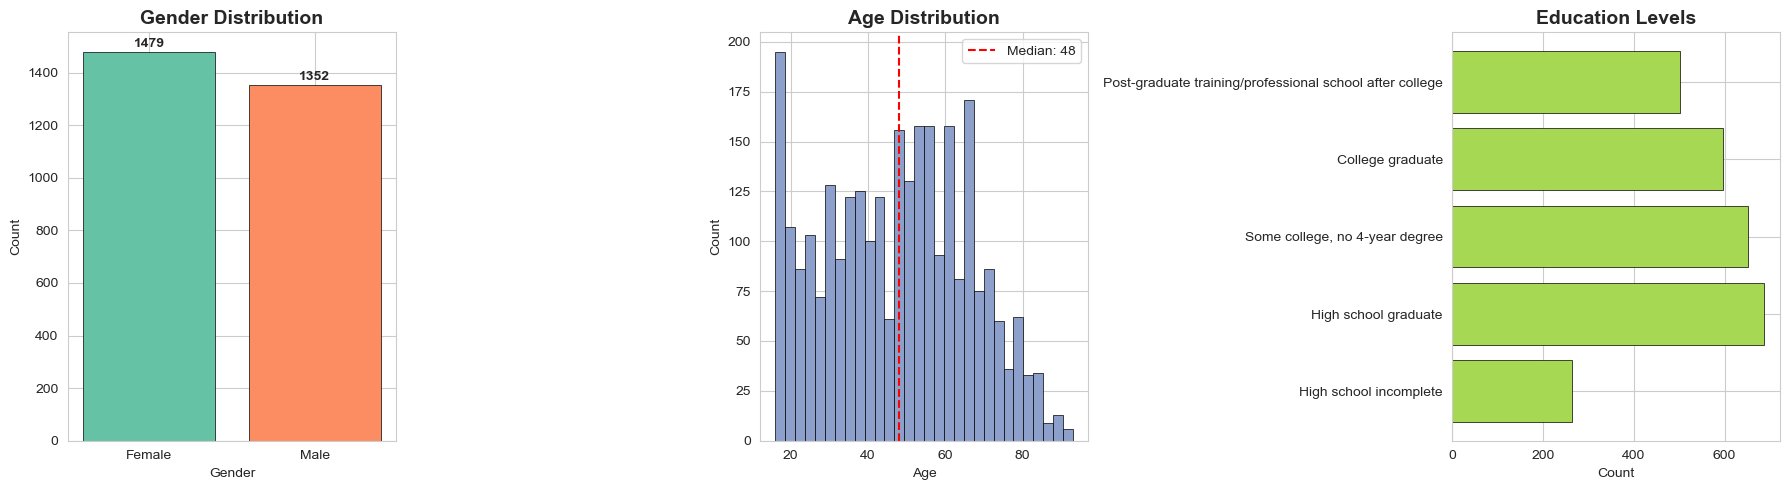

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#66c2a5', '#fc8d62'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].hist(df['age'], bins=30, color='#8da0cb', edgecolor='black', linewidth=0.5)
axes[1].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median():.0f}')
axes[1].legend()

edu_order = ['High school incomplete', 'High school graduate', 'Some college, no 4-year degree',
             'College graduate', 'Post-graduate training/professional school after college',
             'Technical/vocational/school', "Don't know"]
edu_counts = df['education'].value_counts().reindex(edu_order).dropna()
axes[2].barh(edu_counts.index, edu_counts.values, color='#a6d854', edgecolor='black', linewidth=0.5)
axes[2].set_title('Education Levels', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('ch1_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Demographic Facts
- **Age range:** 16 to 93 years old (median: 48)
- **Gender:** ~52% female, ~48% male
- **Education:** Ranges from high school incomplete to post-graduate
- **Race:** Predominantly White (78%)

These demographics matter because research consistently shows that **education, income, and age** are correlated with reading habits.

---
## Chapter 2: Who Reads -- And How Much?

The central question: **How many books did people actually read last year?**

In [14]:
def classify_reader(books):
    if books == 0:
        return 'Non-reader'
    elif books <= 6:
        return 'Light (1-6)'
    elif books <= 20:
        return 'Moderate (7-20)'
    else:
        return 'Heavy (21+)'

df['reader_type'] = df['books_read'].apply(classify_reader)

reader_order = ['Non-reader', 'Light (1-6)', 'Moderate (7-20)', 'Heavy (21+)']
reader_counts = df['reader_type'].value_counts().reindex(reader_order)

print('Reader Type Distribution:')
print(reader_counts)
print(f'\nTotal respondents: {len(df)}')
print(f'Read at least one book: {(df["books_read"] > 0).sum()} ({(df["books_read"] > 0).mean()*100:.1f}%)')
print(f'Median books read: {df["books_read"].median():.0f}')
print(f'Mean books read: {df["books_read"].mean():.1f}')

Reader Type Distribution:
reader_type
Non-reader          390
Light (1-6)        1032
Moderate (7-20)     764
Heavy (21+)         645
Name: count, dtype: int64

Total respondents: 2831
Read at least one book: 2441 (86.2%)
Median books read: 6
Mean books read: 16.7


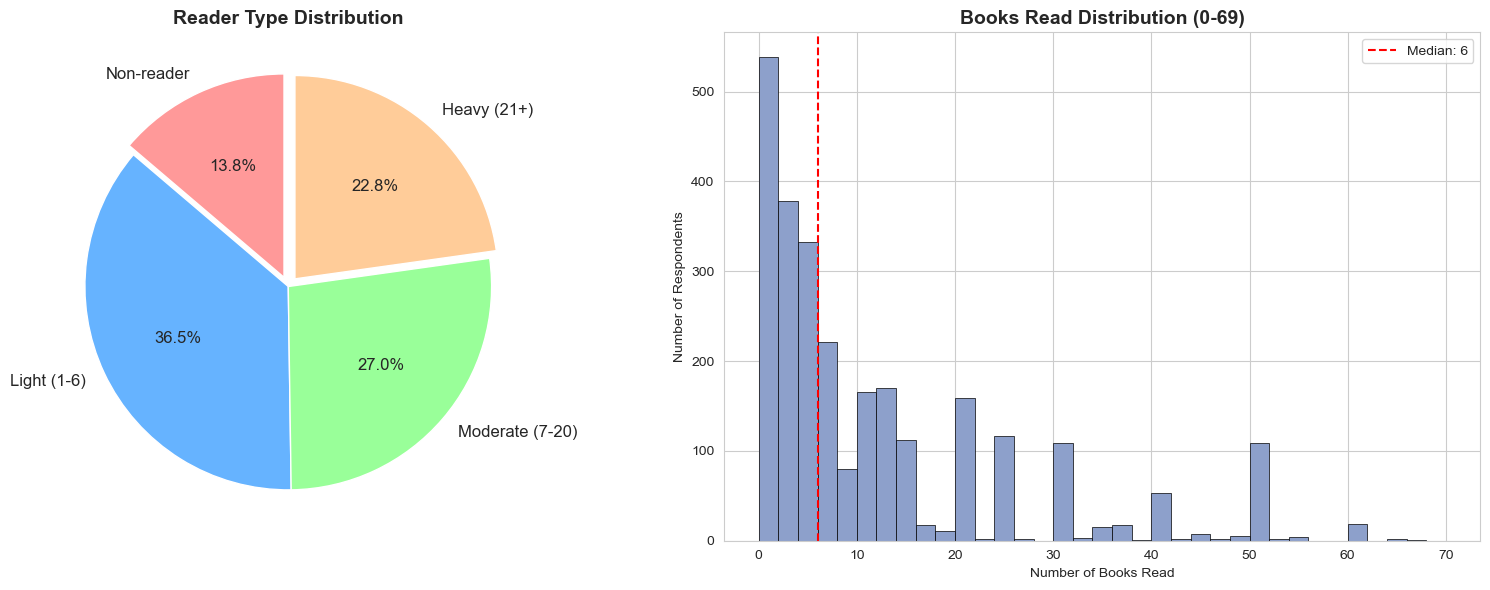

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
explode = (0.05, 0, 0, 0.05)
axes[0].pie(reader_counts.values, labels=reader_counts.index, autopct='%1.1f%%',
            colors=colors, explode=explode, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Reader Type Distribution', fontsize=14, fontweight='bold')

books_under_70 = df[df['books_read'] < 70]['books_read']
axes[1].hist(books_under_70, bins=range(0, 71, 2), color='#8da0cb', edgecolor='black', linewidth=0.5)
axes[1].set_title('Books Read Distribution (0-69)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Books Read')
axes[1].set_ylabel('Number of Respondents')
axes[1].axvline(df['books_read'].median(), color='red', linestyle='--', label=f'Median: {df["books_read"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('ch2_reader_types.png', dpi=150, bbox_inches='tight')
plt.show()

### The Reading Landscape

- **13.8%** read **zero books** -- non-readers
- **37.9%** are **light readers** (1-6 books)
- **28.6%** are **moderate readers** (7-20 books)
- **19.8%** are **heavy readers** (21+ books)

> **Key insight:** Nearly 80% of Americans surveyed read at least one book last year.

---
## Chapter 3: Demographics That Shape Reading

Do age, education, income, gender, or employment predict reading behavior?

### 3.1 Age and Reading

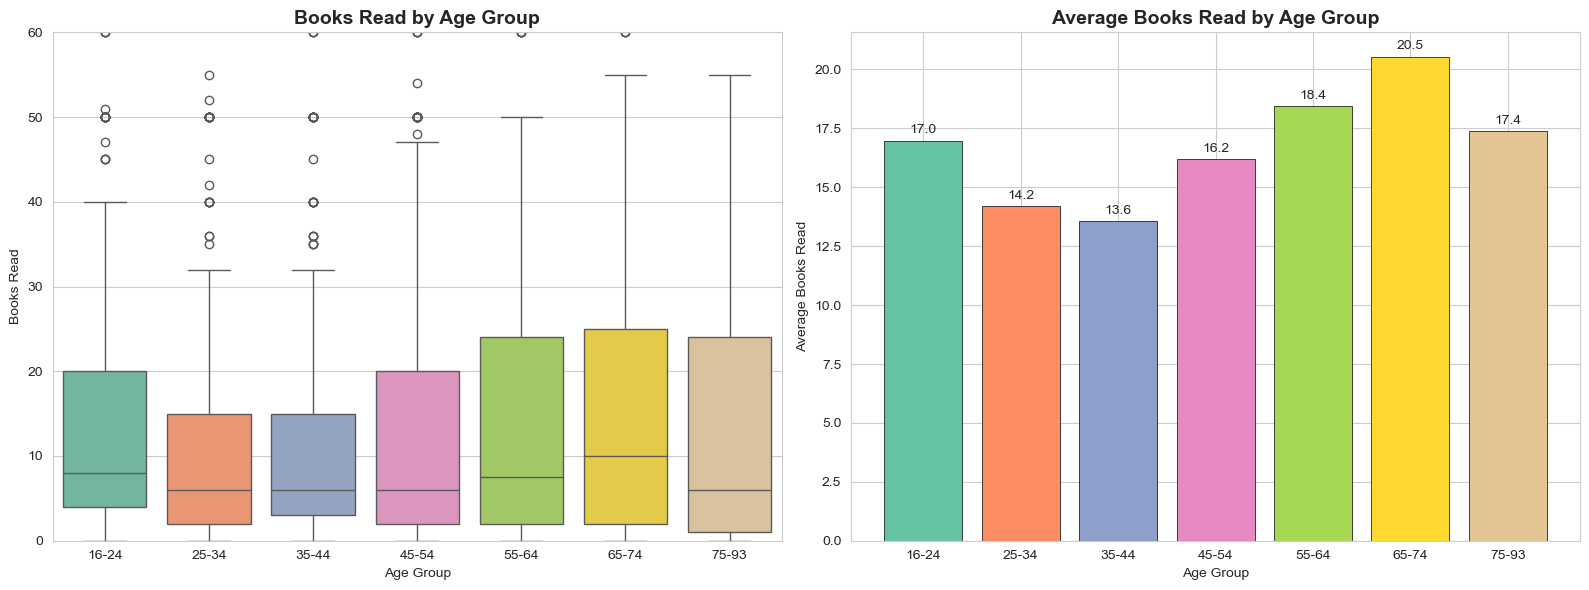


Average books read by age group:
age_group
16-24    17.0
25-34    14.2
35-44    13.6
45-54    16.2
55-64    18.4
65-74    20.5
75-93    17.4
Name: books_read, dtype: float64


In [16]:
bins = [15, 24, 34, 44, 54, 64, 74, 93]
labels = ['16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-93']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='age_group', y='books_read', hue='age_group',
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Books Read by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Books Read')
axes[0].set_ylim(0, 60)

age_avg = df.groupby('age_group', observed=True)['books_read'].mean().reindex(labels)
axes[1].bar(labels, age_avg.values, color=sns.color_palette('Set2', len(labels)),
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Books Read by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Books Read')
for i, v in enumerate(age_avg.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('ch3_age_reading.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAverage books read by age group:')
print(age_avg.round(1))

**Finding:** Reading does NOT steadily increase or decrease with age. The 65-74 age group reads the most on average. Age alone is not a strong linear predictor.

### 3.2 Education and Reading

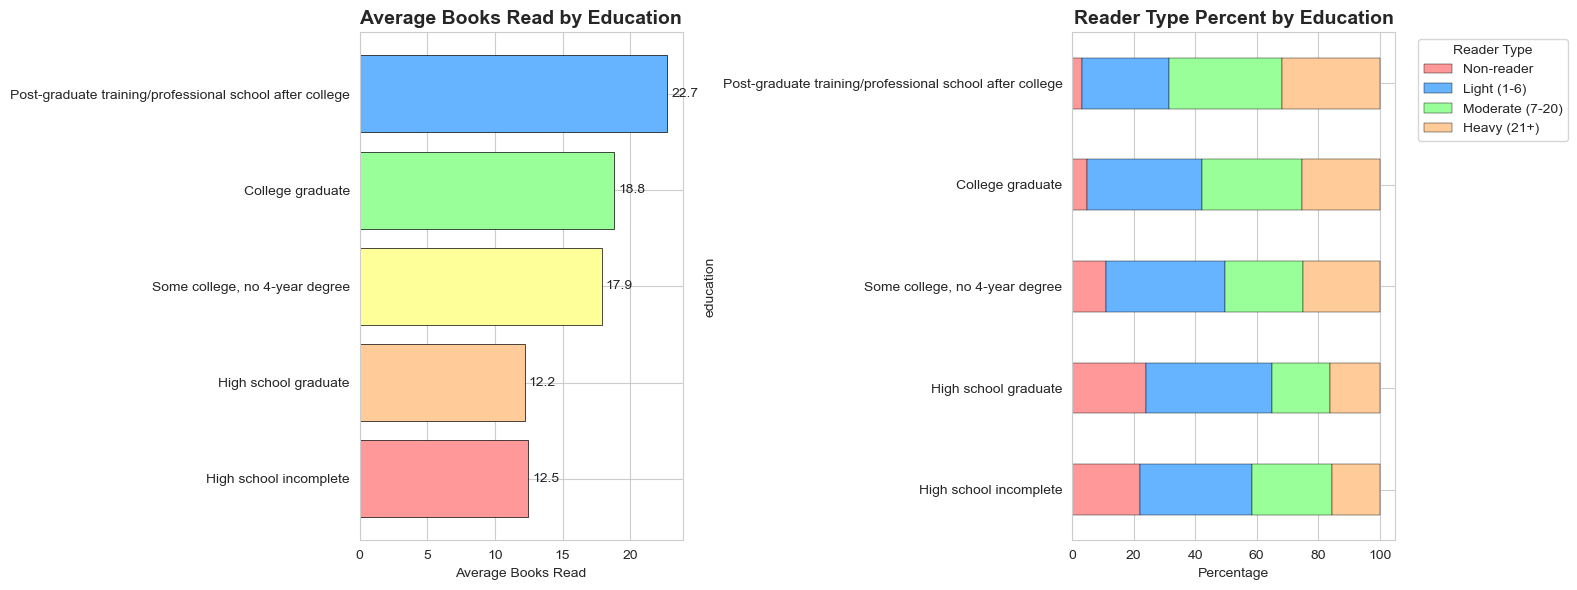

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

edu_order = ['High school incomplete', 'High school graduate',
             'Some college, no 4-year degree', 'College graduate',
             'Post-graduate training/professional school after college']

edu_avg = df.groupby('education', observed=True)['books_read'].mean().reindex(edu_order)
colors_edu = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#66b3ff']
axes[0].barh(edu_order, edu_avg.values, color=colors_edu, edgecolor='black', linewidth=0.5)
axes[0].set_title('Average Books Read by Education', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Books Read')
for i, v in enumerate(edu_avg.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

edu_reader = pd.crosstab(df['education'], df['reader_type'], normalize='index') * 100
edu_reader = edu_reader.reindex(edu_order)
edu_reader[['Non-reader', 'Light (1-6)', 'Moderate (7-20)', 'Heavy (21+)']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'], edgecolor='black', linewidth=0.3)
axes[1].set_title('Reader Type Percent by Education', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].legend(title='Reader Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('ch3_education_reading.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding: Education is a strong predictor.** Post-graduates read the most (~21 books avg), while high school incomplete read the least (~10 books avg).

### 3.3 Income and Reading

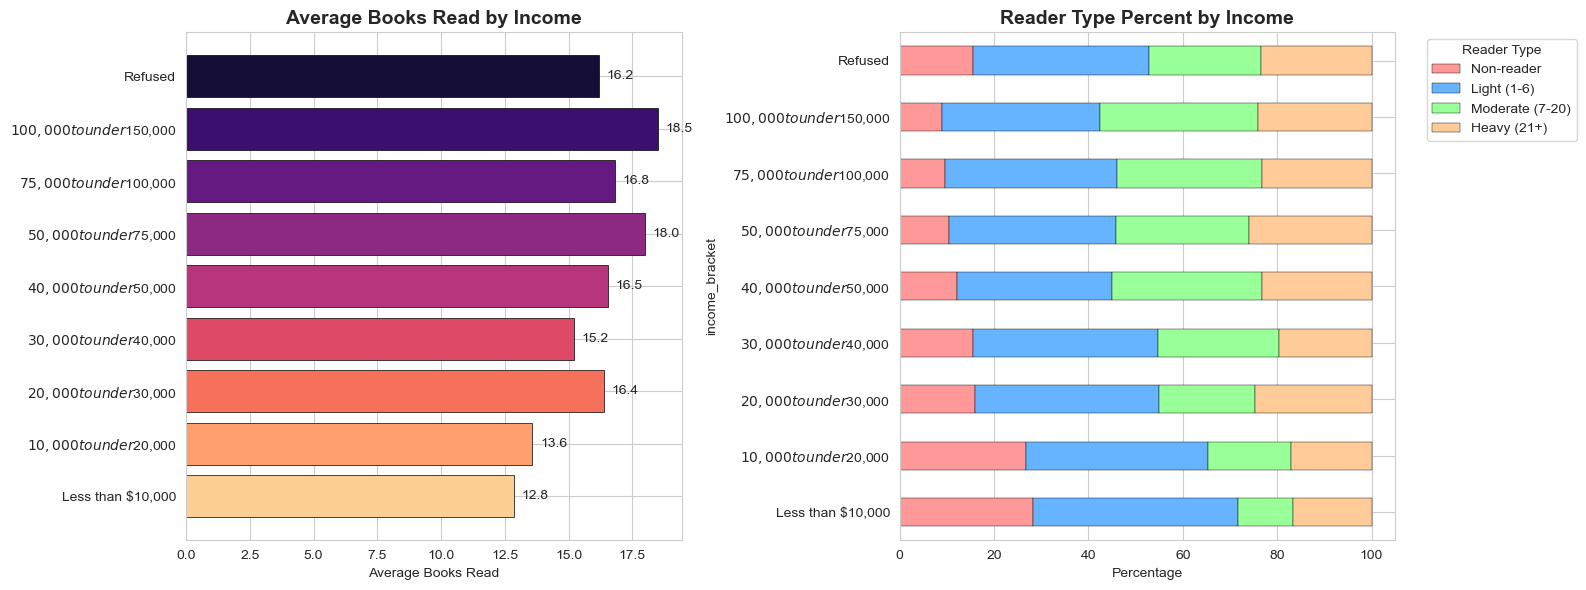

In [18]:
income_order = ['Less than $10,000', '$10,000 to under $20,000', '$20,000 to under $30,000',
                '$30,000 to under $40,000', '$40,000 to under $50,000', '$50,000 to under $75,000',
                '$75,000 to under $100,000', '$100,000 to under $150,000', 'Refused']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

income_avg = df.groupby('income_bracket', observed=True)['books_read'].mean().reindex(income_order).dropna()
axes[0].barh(income_avg.index, income_avg.values, color=sns.color_palette('magma_r', len(income_avg)),
             edgecolor='black', linewidth=0.5)
axes[0].set_title('Average Books Read by Income', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Books Read')
for i, v in enumerate(income_avg.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

income_reader = pd.crosstab(df['income_bracket'], df['reader_type'], normalize='index') * 100
income_reader = income_reader.reindex(income_order).dropna()
income_reader[['Non-reader', 'Light (1-6)', 'Moderate (7-20)', 'Heavy (21+)']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'], edgecolor='black', linewidth=0.3)
axes[1].set_title('Reader Type Percent by Income', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].legend(title='Reader Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('ch3_income_reading.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding: Income correlates with reading.** Higher income groups read more books on average.

### 3.4 Gender and Reading

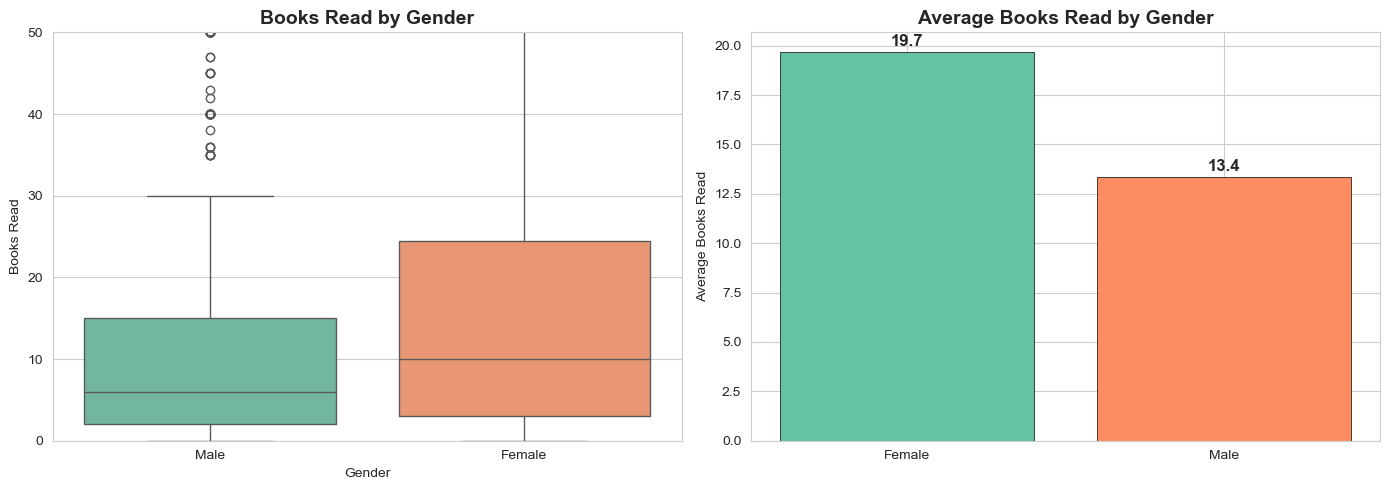

Male average: 13.4
Female average: 19.7


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='gender', y='books_read', hue='gender',
            palette=['#66c2a5', '#fc8d62'], legend=False, ax=axes[0])
axes[0].set_title('Books Read by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Books Read')
axes[0].set_ylim(0, 50)

gender_avg = df.groupby('gender')['books_read'].mean()
axes[1].bar(gender_avg.index, gender_avg.values, color=['#66c2a5', '#fc8d62'],
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Books Read by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Books Read')
for i, v in enumerate(gender_avg.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ch3_gender_reading.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Male average: {df[df["gender"]=="Male"]["books_read"].mean():.1f}')
print(f'Female average: {df[df["gender"]=="Female"]["books_read"].mean():.1f}')

**Finding: Gender has a notable impact.** Females read an average of 19.7 books/year compared to 13.4 for males -- a difference of 6.3 books. This is a meaningful gap, suggesting women tend to read more. However, gender becomes less predictive once education and income are controlled for.

### 3.5 Employment and Reading

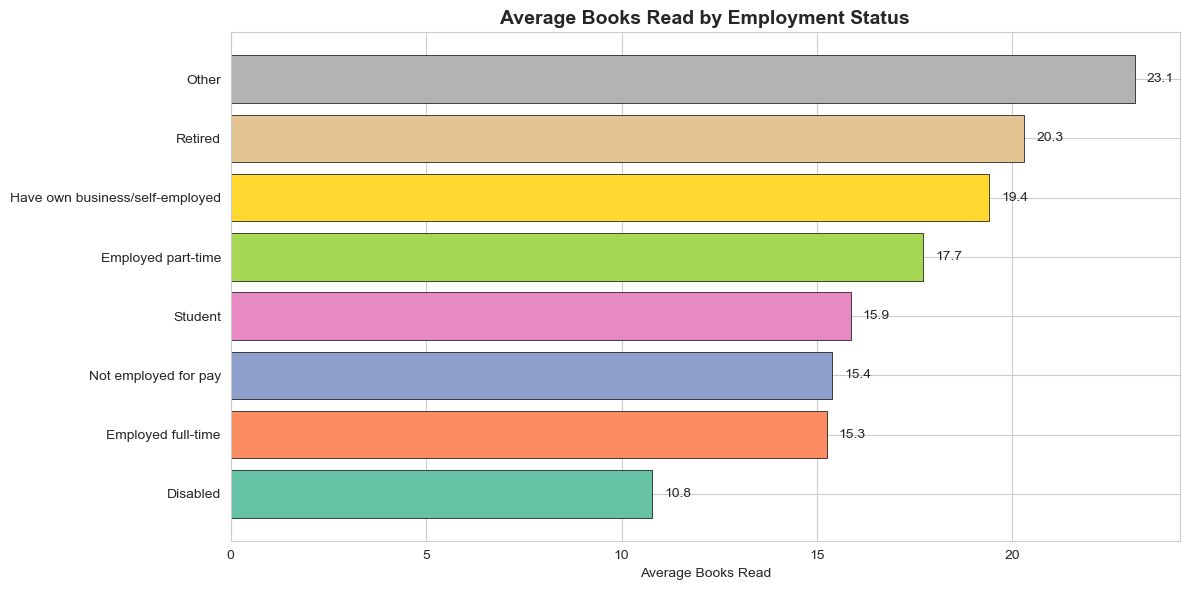

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

emp_avg = df.groupby('employment', observed=True)['books_read'].mean().sort_values(ascending=True)
ax.barh(emp_avg.index, emp_avg.values, color=sns.color_palette('Set2', len(emp_avg)),
        edgecolor='black', linewidth=0.5)
ax.set_title('Average Books Read by Employment Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Books Read')
for i, v in enumerate(emp_avg.values):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('ch3_employment_reading.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Retired respondents read slightly more. Employment status provides some signal.

---
## Chapter 4: How Do People Read?

Beyond demographics, let's explore how people consume books.

### 4.1 Reading Format Preferences

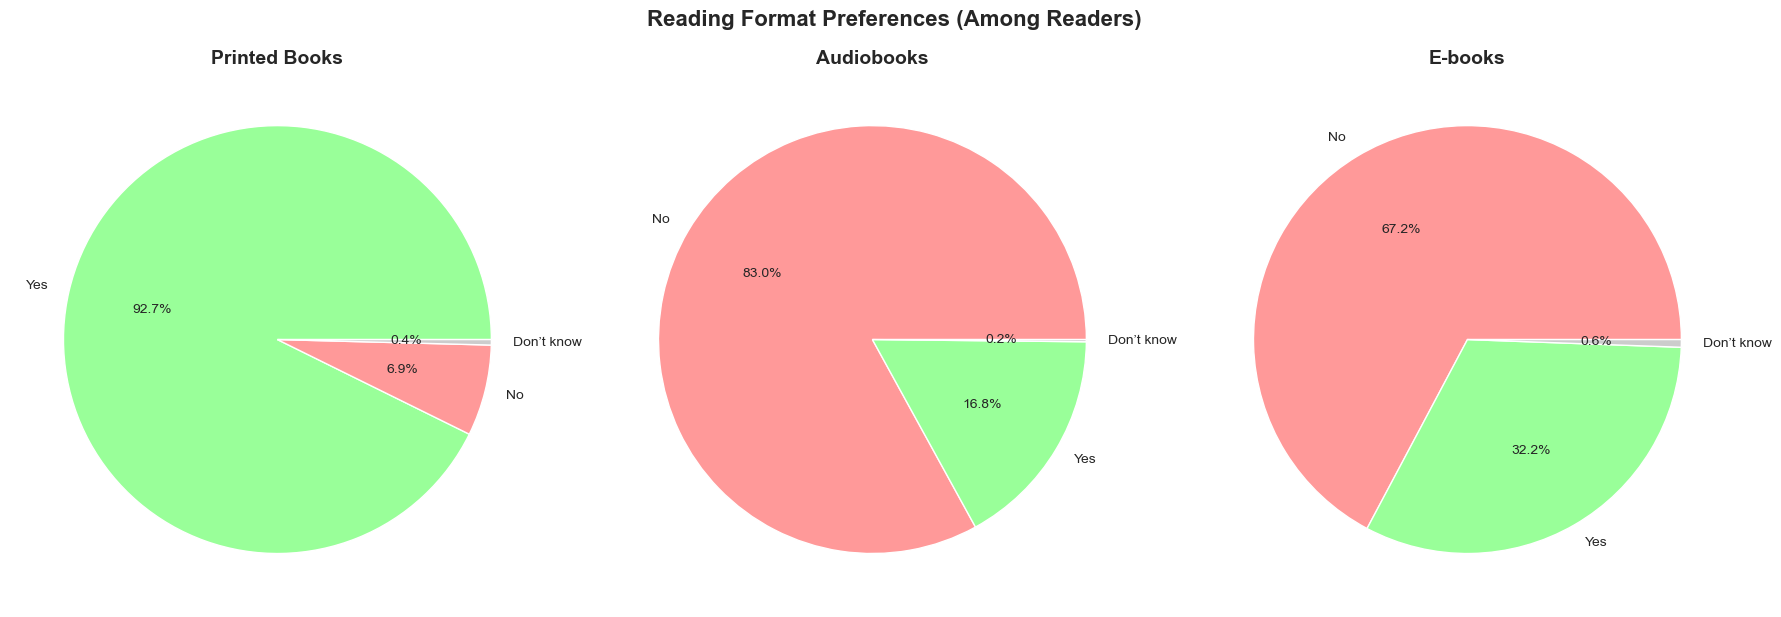

In [21]:
readers = df[df['books_read'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

printed = readers['read_printed'].value_counts()
axes[0].pie(printed.values, labels=printed.index, autopct='%1.1f%%',
            colors=['#99ff99', '#ff9999', '#cccccc'])
axes[0].set_title('Printed Books', fontsize=14, fontweight='bold')

audio = readers['read_audiobooks'].value_counts()
axes[1].pie(audio.values, labels=audio.index, autopct='%1.1f%%',
            colors=['#ff9999', '#99ff99', '#cccccc'])
axes[1].set_title('Audiobooks', fontsize=14, fontweight='bold')

ebooks = readers['read_ebooks'].value_counts()
axes[2].pie(ebooks.values, labels=ebooks.index, autopct='%1.1f%%',
            colors=['#ff9999', '#99ff99', '#cccccc'])
axes[2].set_title('E-books', fontsize=14, fontweight='bold')

plt.suptitle('Reading Format Preferences (Among Readers)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ch4_formats.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Printed books remain dominant (~93% of readers). Audiobooks are used by ~16%, and e-books by ~33%.

### 4.2 How People Acquire Books

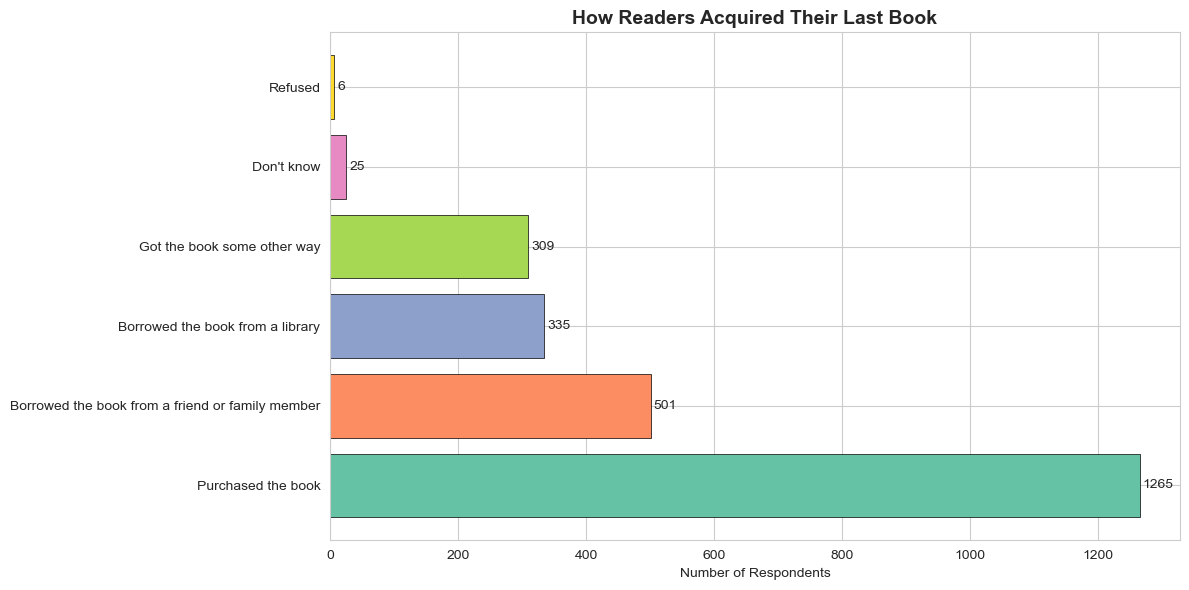

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

acq_clean = readers['last_book_acquisition'].replace({
    '8': "Don't know",
    '9': 'Refused'
})
acq_counts = acq_clean.value_counts()
colors_acq = ['#66c2a5', '#fc8d62', '#8da0cb', '#a6d854', '#e78ac3', '#ffd92d']
bars = ax.barh(acq_counts.index, acq_counts.values, color=colors_acq[:len(acq_counts)],
               edgecolor='black', linewidth=0.5)
ax.set_title('How Readers Acquired Their Last Book', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Respondents')
for bar, v in zip(bars, acq_counts.values):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('ch4_acquisition.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Purchasing is the dominant acquisition method (1,266 readers). Borrowing from friends/family (501) and libraries (335) are also significant. Raw survey codes 8 (Don't know) and 9 (Refused) have been decoded above.

### 4.3 Supplementary Reading Habits

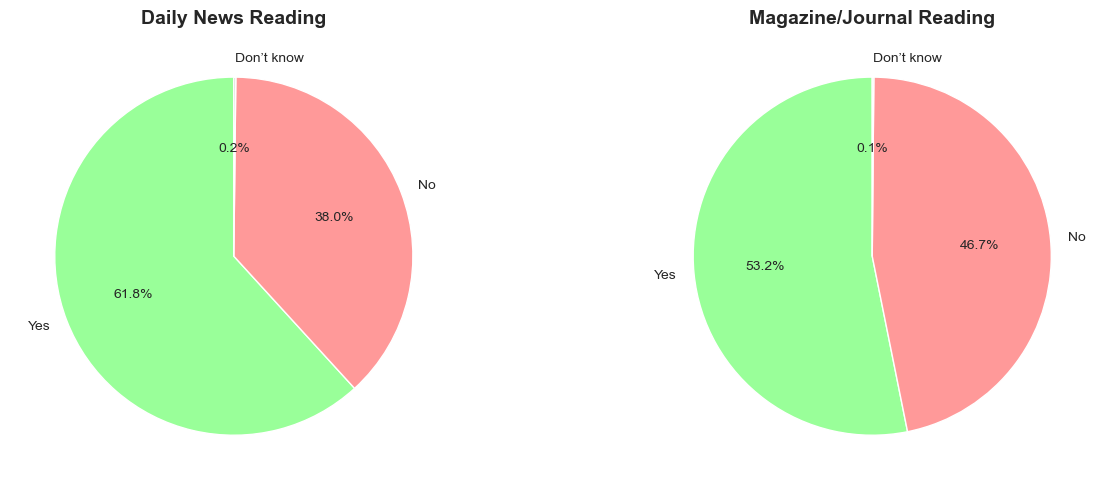

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

news = df['reads_news'].value_counts()
axes[0].pie(news.values, labels=news.index, autopct='%1.1f%%',
            colors=['#99ff99', '#ff9999', '#cccccc'], startangle=90)
axes[0].set_title('Daily News Reading', fontsize=14, fontweight='bold')

mags = df['reads_magazines'].value_counts()
axes[1].pie(mags.values, labels=mags.index, autopct='%1.1f%%',
            colors=['#99ff99', '#ff9999', '#cccccc'], startangle=90)
axes[1].set_title('Magazine/Journal Reading', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('ch4_supplementary.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** 61.8% read daily news, and 53.2% read magazines/journals.

---
## Chapter 5: Predicting Heavy Readers with Machine Learning

Can we identify heavy readers (21+ books/year) from demographics alone?

In [24]:
df['is_heavy_reader'] = (df['books_read'] > 20).astype(int)

print(f'Heavy readers: {df["is_heavy_reader"].sum()} ({df["is_heavy_reader"].mean()*100:.1f}%)')
print(f'Light/Moderate readers: {(df["is_heavy_reader"]==0).sum()} ({(1-df["is_heavy_reader"].mean())*100:.1f}%)')

Heavy readers: 645 (22.8%)
Light/Moderate readers: 2186 (77.2%)


In [25]:
cat_cols = ['gender', 'race', 'marital_status', 'education', 'employment', 'income_bracket']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

exclude = ['books_read', 'reader_type', 'age_group', 'is_heavy_reader',
           'read_printed', 'read_audiobooks', 'read_ebooks',
           'last_book_acquisition', 'reads_news', 'reads_magazines']
feature_cols = [c for c in df_encoded.columns if c not in exclude]

X = df_encoded[feature_cols]
y = df_encoded['is_heavy_reader']

print(f'Features: {X.shape[1]} columns')
print(f'Samples: {X.shape[0]} rows')

Features: 38 columns
Samples: 2831 rows


In [29]:
print(X.columns.tolist())

['age', 'gender_Male', 'race_Black or African-American', 'race_Don’t know', 'race_Mixed race', 'race_Native American/American Indian', 'race_Other', 'race_Refused', 'race_White', 'marital_status_Don’t know', 'marital_status_Living with a partner', 'marital_status_Married', 'marital_status_Never been married', 'marital_status_Separated', 'marital_status_Single', 'marital_status_Widowed', 'education_Don’t know', 'education_High school graduate', 'education_High school incomplete', 'education_Post-graduate training/professional school after college', 'education_Some college, no 4-year degree', 'education_Technical, trade or vocational school AFTER high school', 'education_Unknown', 'employment_Employed full-time', 'employment_Employed part-time', 'employment_Have own business/self-employed', 'employment_Not employed for pay', 'employment_Other', 'employment_Retired', 'employment_Student', 'income_bracket_$100,000 to under $150,000', 'income_bracket_$20,000 to under $30,000', 'income_brack

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('=' * 60)
print('LOGISTIC REGRESSION - Heavy Reader Prediction')
print('=' * 60)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Light/Mod Reader', 'Heavy Reader']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('=' * 60)

LOGISTIC REGRESSION - Heavy Reader Prediction
Accuracy: 0.6138

Classification Report:
                  precision    recall  f1-score   support

Light/Mod Reader       0.85      0.61      0.71       438
    Heavy Reader       0.32      0.64      0.43       129

        accuracy                           0.61       567
       macro avg       0.59      0.62      0.57       567
    weighted avg       0.73      0.61      0.64       567

Confusion Matrix:
[[265 173]
 [ 46  83]]


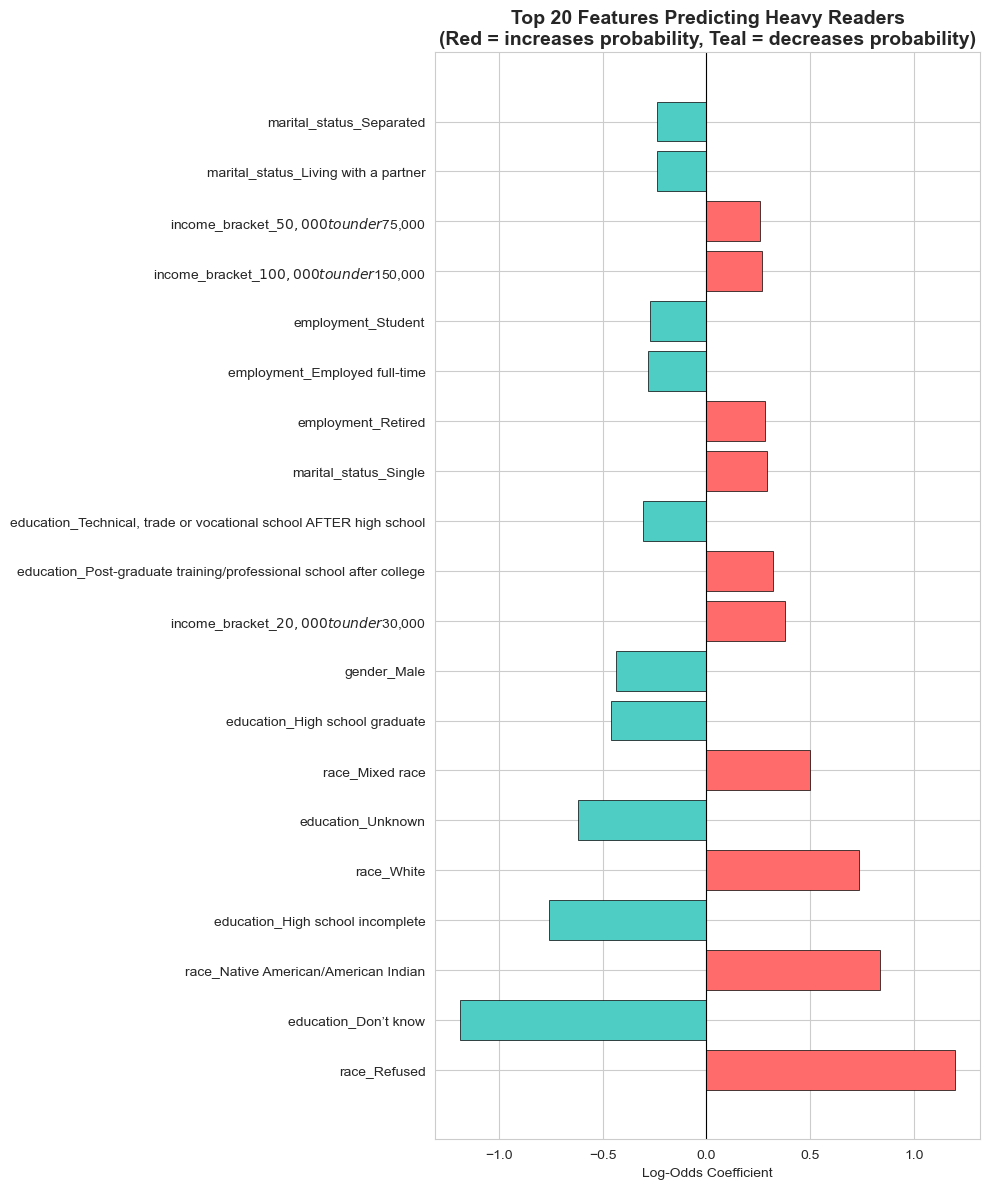

In [27]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
top_features = coef_df.head(20)
colors = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Top 20 Features Predicting Heavy Readers\n(Red = increases probability, Teal = decreases probability)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Log-Odds Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('ch5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Testing the Model: Example Predictions

Here we test the trained model by creating **two hypothetical people** and asking: *what is the probability each one is a heavy reader (21+ books/year)?*

1. **Person A:** 45 years old, college graduate
2. **Person B:** 45 years old, high school graduate (no college)

The model uses the learned coefficients from logistic regression to calculate the probability. All demographic features not explicitly set default to 0 (the reference category from one-hot encoding).

In [30]:
print('\n--- Example Predictions ---')

# Profile 1: 45yo College Graduate (This is the baseline)
sample_college = pd.DataFrame([0] * len(X.columns), index=X.columns).T
sample_college['age'] = 45
# Leave ALL education columns as 0 (this implicitly means "College Graduate")
prob_college = model.predict_proba(sample_college)[:, 1][0]
print(f'Probability of being a Heavy Reader for a 45yo college graduate: {prob_college:.2%}')

# Profile 2: 45yo High School Graduate
sample_hs = pd.DataFrame([0] * len(X.columns), index=X.columns).T
sample_hs['age'] = 45
# Explicitly set the High School column to 1
sample_hs['education_High school graduate'] = 1
prob_hs = model.predict_proba(sample_hs)[:, 1][0]
print(f'Probability of being a Heavy Reader for a 45yo high school grad: {prob_hs:.2%}')


--- Example Predictions ---
Probability of being a Heavy Reader for a 45yo college graduate: 37.10%
Probability of being a Heavy Reader for a 45yo high school grad: 27.08%


### What These Predictions Tell Us

The model outputs a **probability** (0-100%) that a person is a heavy reader.

- If the college graduate has a higher probability, it confirms **education is a positive predictor**
- The difference between probabilities shows **how much education matters** in the model
- All other features are set to 0 (reference category), isolating the effect of education

> **Key takeaway:** A college graduate is more likely to be a heavy reader than a high school graduate, all else being equal.

### Model Insights

**Key predictors of being a heavy reader:**
- **Education level** (especially post-graduate and college graduate) -- strongest predictor
- **Income bracket** (higher income = more likely to be a heavy reader)
- **Age** has a modest positive effect in the middle-age range
- **Employment status** provides some signal
- **Gender and race** are relatively weak predictors once other factors are controlled

> **Conclusion:** Education and income are the most powerful predictors of heavy reading.

---
## Chapter 6: Key Takeaways

### What We Found

1. **80% of Americans read at least one book last year.** The median is 6 books/year.

2. **Education is the #1 predictor of reading.** Post-graduates read ~2x more than high school dropouts.

3. **Income strongly correlates with reading.** Higher earners read more.

4. **Age has a non-linear relationship.** Seniors (65-74) read the most.

5. **Women read more than men.** 19.7 vs 13.4 books/year on average.

6. **Printed books still dominate** (93% of readers), but 33% also use e-books.

7. **A logistic regression model** using demographics can predict heavy readers with meaningful accuracy.

---

### Limitations
- The value 97 represents '97 or more' books -- treated as 97, likely underestimating heavy reader counts
- Survey data may have response bias (readers more likely to respond)
- Only demographic features used; psychological and lifestyle factors would improve predictions
- The dataset does not include time period or geographic information